# Notebook_B (Sinh viên B): chia dữ liệu, năm mô hình, tinh chỉnh, RQ3, SHAP, chẩn đoán

**Đề tài**: Chất lượng nước sông 3 ngày tại 30 trạm USGS (NWIS)

**Khung SDG**: SDG 6 và 14: "water governance", "river restoration".

**Vai trò**: Sinh viên B nhận `data/processed/feat.parquet` và `manifest.json` từ Notebook_A, làm Bước 4 và Bước 6, vẽ hình so sánh mô hình, giải thích chỉ số, tinh chỉnh, câu hỏi thứ ba, SHAP và chẩn đoán vì sao tốt hay chưa tốt. Mọi bảng lưu `report/table_*.csv`, mọi hình `report/fig_rq2_*.png`, `fig_rq3_*.png`.

**Quy tắc**: không chạm tập kiểm thử khi tinh chỉnh; mỗi kết luận phải kèm số; báo cáo slot 3 thứ Tư và thứ Bảy (12:30 đến 14:45).

## Vừa làm vừa hỏi AI và ghi Audit Log: cách làm nhẹ nhàng, không rối

**Tinh thần**: AI là bạn cùng làm, không phải người làm thay. Bạn được hỏi AI bất cứ lúc nào; điều duy nhất phải giữ là *kiểm tra một lần* trước khi dùng và *ghi lại 2 phút* nếu câu hỏi đó thay đổi việc bạn làm.

**Khi nào hỏi AI** (theo thứ tự):
1. Đọc ô hướng dẫn của bước đang làm (1 phút).
2. Thử tự làm 15 phút.
3. Bí quá 15 phút thì hỏi AI với mẫu: *"Tôi đang làm Bước X của dự án Y. Dữ liệu có cột A, B, C. Tôi muốn Z. Đây là code và lỗi: ... Hãy giải thích nguyên nhân và sửa, giữ nguyên tên biến."*
4. Chạy thử code AI đưa trên dữ liệu thật; so một con số bằng tay hoặc bằng cách thứ hai.
5. Nếu vẫn bí sau 30 phút, ghi lại lỗi và hỏi giảng viên ở kênh nhóm.

**Ghi Audit Log thế nào cho không áp lực**: chỉ ghi các prompt *đã thay đổi việc bạn làm* (thường 3 đến 5 prompt một tuần, 15 đến 20 cả kỳ). Mỗi dòng 5 ô, điền trong 2 phút ngay khi dùng, không để cuối tuần:

| Ngày, bước | Prompt (rút gọn) | AI trả lời gì (1 dòng) | Tôi kiểm tra hoặc sửa gì | Dùng vào đâu |
|---|---|---|---|---|
| 09/09, Bước 3 | viết truy vấn trung bình trượt 7 ngày theo trạm | đưa AVG OVER ROWS 6 PRECEDING | thiếu PARTITION BY site_num, thêm và thử 2 trạm | Q3 trong sql/queries.sql |

Cột thứ tư chính là *Human Delta* và là thứ hội đồng hỏi; ghi thật, kể cả khi AI đúng ("kiểm tra bằng 10 dòng tính tay, khớp"). Ba lần bạn phát hiện AI sai trong cả kỳ là đủ yêu cầu.

**Nhịp làm việc**: mỗi ngày 1,5 đến 2 giờ vào đúng bước của tuần, xong một ô thì commit; thứ Ba và thứ Sáu slot 1 báo cáo năm mục đúng tiến độ, dù kết quả chưa đẹp. Siêng và đúng nhịp quan trọng hơn giỏi: nhóm báo cáo đều 6 lần trong 3 tuần luôn có bài, nhóm im lặng đến tuần 3 thường không kịp.

## Bước 0: kiểm tra bàn giao từ Notebook_A

Đọc `manifest.json`, so mã băm và số dòng với file parquet; nếu lệch thì báo Sinh viên A chạy lại Notebook_A trước khi tiếp tục.

In [1]:
import pandas as pd, numpy as np, json, hashlib, duckdb, warnings, time
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore'); np.random.seed(42)
from sklearn.metrics import mean_absolute_error as MAE, mean_squared_error as MSE, f1_score, average_precision_score, roc_auc_score
man = json.load(open('data/processed/manifest.json'))
h = hashlib.md5(open('data/processed/feat.parquet', 'rb').read()).hexdigest()
assert h == man['md5'], 'parquet differs from the file handed over by Student A'
feat = pd.read_parquet('data/processed/feat.parquet')
assert len(feat) == man['rows'], 'row count differs from manifest'
con = duckdb.connect()
con.register('feat', feat)          # expose the handed-over table to SQL in this notebook
print('handover OK:', man['rows'], 'rows,', len(man['cols']), 'columns, from', man['time_min'], 'to', man['time_max'])
def style(ax): ax.spines[['top', 'right']].set_visible(False)

handover OK: 86444 rows, 22 columns, from 2018-01-01 00:00:00 to 2026-09-14 00:00:00


## Bước 4: chia dữ liệu và bảng đặc trưng

**Làm gì**: chọn `X_cols` từ `report/table_columns.csv` của A (không dùng station ID khi đánh giá Leave-Units-Out); chia theo thời gian (hoặc theo đơn vị với leave-out); tính mốc naive; xuất bảng đặc trưng (tên, cách tính, nhóm) cho bài.

**Vì sao chia theo thời gian**: dữ liệu tương lai không được rò vào huấn luyện; chia ngẫu nhiên cho kết quả đẹp giả (Bergmeir và Benitez, 2012).

**Kiểm tra**: mọi thời điểm của test sau train; số dòng test đủ lớn (trên 10% và trên 3 nghìn dòng).

In [2]:
# --- BƯỚC 1+2: tạo lại feat, train, test (bản gốc đầu tiên trong notebook) ---
feat = con.execute("""
    SELECT * FROM feat WHERE y_wt_3d IS NOT NULL AND wt_lag7 IS NOT NULL AND wtemp IS NOT NULL""").df()
feat['date'] = pd.to_datetime(feat['date'])
feat = feat.sort_values(['date', 'station']).reset_index(drop=True)

train = feat[feat.date < '2023-01-01']
test = feat[feat.date >= '2023-01-01']

print('train:', len(train), '| test:', len(test))

train: 39932 | test: 42884


In [3]:
# ============================================================
# BƯỚC 4 (BẢN B): Imputation theo cấu trúc missing
#   - MAR_COLS: nội suy theo thời gian, theo từng trạm (giữ tính mùa vụ)
#   - MNAR_COLS: KHÔNG suy diễn giá trị — thêm cờ *_is_missing + fill
#     bằng median-train (thiếu cấu trúc do thiết bị, không phải ngẫu nhiên)
#   - Mọi thống kê (median) chỉ fit trên TRAIN, không dùng test
# ============================================================

# --- Reset X_cols về danh sách gốc — bắt buộc, tránh cộng dồn qua nhiều lần chạy cell ---
X_cols = ['wtemp','wt_lag1','wt_lag7','wt_ma7','dox','do_lag1','do_ma7','turb','flow',
          'PRCP','prcp3','TMAX','tmax3','doy','mon']

MAR_COLS  = ['wtemp', 'wt_lag1', 'wt_lag7', 'wt_ma7', 'flow', 'PRCP', 'prcp3', 'TMAX', 'tmax3']
MNAR_COLS = ['dox', 'turb']                 # thiếu cấu trúc gốc (trạm không có cảm biến)
DERIVED_MNAR_COLS = ['do_lag1', 'do_ma7']   # phụ thuộc dox -> cùng bản chất MNAR

def interpolate_by_station(df, cols, max_gap_days=5):
    """Nội suy theo thời gian cho từng trạm, chỉ lấp gap ngắn (<= max_gap_days)."""
    df = df.sort_values(['station', 'date']).copy()
    parts = []
    for station, g in df.groupby('station'):
        g = g.set_index('date')
        g[cols] = g[cols].interpolate(method='time', limit=max_gap_days, limit_direction='both')
        parts.append(g.reset_index())
    return pd.concat(parts, ignore_index=True).sort_values(['date', 'station']).reset_index(drop=True)

# --- 1) Nội suy các cột MAR theo trạm (train/test riêng biệt, không rò rỉ) ---
mar_cols_present = [c for c in MAR_COLS if c in X_cols]
train_interp = interpolate_by_station(train, mar_cols_present)
test_interp  = interpolate_by_station(test,  mar_cols_present)

X_tr = train_interp[X_cols].copy()
X_te = test_interp[X_cols].copy()
y_tr, y_te = train.y_wt_3d, test.y_wt_3d

# --- 2) Cờ missing + fill cho MNAR gốc (dox, turb) ---
mnar_cols_present = [c for c in MNAR_COLS if c in X_cols]
for col in mnar_cols_present:
    flag_col = f'{col}_is_missing'
    X_tr[flag_col] = X_tr[col].isna().astype(int)
    X_te[flag_col] = X_te[col].isna().astype(int)
    fill_value = X_tr[col].median()
    X_tr[col] = X_tr[col].fillna(fill_value)
    X_te[col] = X_te[col].fillna(fill_value)
    print(f'{col}: fill_value={round(fill_value, 3)} | train missing={X_tr[flag_col].mean():.2%} | test missing={X_te[flag_col].mean():.2%}')
    X_cols = X_cols + [flag_col]

# --- 3) Cờ missing + fill cho MNAR phái sinh (do_lag1, do_ma7) ---
derived_cols_present = [c for c in DERIVED_MNAR_COLS if c in X_cols]
for col in derived_cols_present:
    flag_col = f'{col}_is_missing'
    X_tr[flag_col] = X_tr[col].isna().astype(int)
    X_te[flag_col] = X_te[col].isna().astype(int)
    fill_value = X_tr[col].median()
    X_tr[col] = X_tr[col].fillna(fill_value)
    X_te[col] = X_te[col].fillna(fill_value)
    print(f'{col}: fill_value={round(fill_value, 3)} | train missing={X_tr[flag_col].mean():.2%} | test missing={X_te[flag_col].mean():.2%}')
    X_cols = X_cols + [flag_col]

# --- 4) Gộp cờ trùng lặp (dox_is_missing ~ do_lag1_is_missing/do_ma7_is_missing) ---
overlap = (X_tr['dox_is_missing'] == X_tr['do_lag1_is_missing']).mean()
print('Trùng lặp giữa dox_is_missing và do_lag1_is_missing:', f'{overlap:.2%}')
if overlap > 0.95:
    X_tr = X_tr.drop(columns=['do_lag1_is_missing', 'do_ma7_is_missing'])
    X_te = X_te.drop(columns=['do_lag1_is_missing', 'do_ma7_is_missing'])
    X_cols = [c for c in X_cols if c not in ('do_lag1_is_missing', 'do_ma7_is_missing')]
    print('Đã gộp: giữ lại dox_is_missing làm cờ đại diện.')

# --- 5) Kiểm tra & xử lý NaN còn sót — KHÔNG fill im lặng, in rõ từng cột ---
remaining_nan_tr = X_tr[X_cols].isna().sum().sum()
remaining_nan_te = X_te[X_cols].isna().sum().sum()
print('NaN còn lại sau bước 1-4 — train:', int(remaining_nan_tr), '| test:', int(remaining_nan_te))

if remaining_nan_tr > 0 or remaining_nan_te > 0:
    for col in X_cols:
        n_left_tr = X_tr[col].isna().sum()
        n_left_te = X_te[col].isna().sum()          # ← THÊM: đếm riêng cho test
        if n_left_tr > 0 or n_left_te > 0:            # ← SỬA: kiểm tra cả hai
            n_original = train[col].isna().sum() if col in train.columns else None
            fv = X_tr[col].median()                   # fit median chỉ trên TRAIN — đúng nguyên tắc
            X_tr[col] = X_tr[col].fillna(fv)
            X_te[col] = X_te[col].fillna(fv)
            print(f'  {col}: còn {n_left_tr} NaN (train) / {n_left_te} NaN (test) sau nội suy (gap > {5} ngày) | '
                  f'NaN gốc trong train={n_original} -> fill median-train={round(fv, 3)}')

# --- Mốc naive (persistence): dùng DUY NHẤT ở đây, các bước sau chỉ đọc lại biến `naive` ---
naive_pred = test.wtemp
naive = MAE(y_te, naive_pred)
print('MAE naive (persistence):', round(naive, 3))

dox: fill_value=10.1 | train missing=5.46% | test missing=17.22%
turb: fill_value=4.0 | train missing=4.43% | test missing=4.90%
do_lag1: fill_value=10.1 | train missing=5.54% | test missing=17.24%
do_ma7: fill_value=10.071 | train missing=4.87% | test missing=16.96%
Trùng lặp giữa dox_is_missing và do_lag1_is_missing: 99.63%
Đã gộp: giữ lại dox_is_missing làm cờ đại diện.
NaN còn lại sau bước 1-4 — train: 1974 | test: 3310
  flow: còn 0 NaN (train) / 8 NaN (test) sau nội suy (gap > 5 ngày) | NaN gốc trong train=0 -> fill median-train=233.0
  PRCP: còn 380 NaN (train) / 738 NaN (test) sau nội suy (gap > 5 ngày) | NaN gốc trong train=1723 -> fill median-train=0.0
  prcp3: còn 364 NaN (train) / 607 NaN (test) sau nội suy (gap > 5 ngày) | NaN gốc trong train=710 -> fill median-train=3.2
  TMAX: còn 638 NaN (train) / 1012 NaN (test) sau nội suy (gap > 5 ngày) | NaN gốc trong train=1916 -> fill median-train=18.9
  tmax3: còn 592 NaN (train) / 945 NaN (test) sau nội suy (gap > 5 ngày) | NaN 

### 6.0. Giải thích các chỉ số trước khi chạy

| Chỉ số | Công thức | Dùng khi | Đọc thế nào | Bẫy thường gặp |
|---|---|---|---|---|
| MAE | trung bình của |y − ŷ| | hồi quy, đơn vị như mục tiêu | càng nhỏ càng tốt; so với mốc naive | không phạt lỗi lớn |
| RMSE | căn của trung bình (y − ŷ)² | khi lỗi lớn quan trọng (lũ, đỉnh tải) | lớn hơn MAE nếu có lỗi lớn | nhạy ngoại lai |
| MAPE | trung bình của |y − ŷ| / |y| | so sánh giữa vùng có quy mô khác nhau | phần trăm | nổ khi y gần 0 |
| nRMSE | RMSE chia công suất định mức | điện mặt trời, gió | phần trăm định mức | cần cùng định mức |
| NSE | 1 − Σ(y − ŷ)² / Σ(y − ȳ)² | thuỷ văn | 1 là hoàn hảo, 0 bằng trung bình, âm tệ hơn trung bình | bị chi phối bởi đỉnh |
| Accuracy | đúng / tổng | lớp cân bằng | vô nghĩa khi lớp ít mẫu | 95% accuracy với 5% dương |
| Precision, Recall | TP/(TP+FP), TP/(TP+FN) | cảnh báo, lớp ít mẫu | recall là không bỏ sót; precision là ít báo giả | phụ thuộc ngưỡng |
| F1, macro-F1 | trung bình điều hoà; macro là trung bình các lớp | nhiều lớp lệch | mọi lớp có trọng số bằng nhau | che giấu lớp nào yếu |
| PR-AUC | diện tích đường precision-recall | lớp dương hiếm | không phụ thuộc ngưỡng | so với tỷ lệ dương |
| ROC-AUC | diện tích đường ROC | xếp hạng | 0,5 là ngẫu nhiên | lạc quan khi lớp lệch |
| ECE | Σ |acc − conf| có trọng số theo bin | cần xác suất tin được | càng nhỏ càng tốt | phụ thuộc số bin |
| Coverage | tỷ lệ y nằm trong khoảng | conformal | phải gần 1 − α | khoảng quá rộng vô dụng |

**Nguyên tắc so sánh**: cùng train/test, cùng đặc trưng, năm seed; báo trung bình ± độ lệch; chênh nhỏ hơn độ lệch thì chưa kết luận được, cần kiểm định Wilcoxon theo cặp; luôn kèm cột thời gian huấn luyện.

## Bước 6a: năm mô hình, năm seed, cùng train/test

**Làm gì**: chạy vòng lặp; thêm hàng mốc naive (từ Bước 4) và hàng baseline chạy lại vào bảng; lưu `table_rq2.csv`.

**Cách chọn năm mô hình**: một mốc tuyến tính (ridge hoặc logistic), một rừng ngẫu nhiên, hai cây tăng cường (LightGBM, XGBoost hoặc CatBoost), một đối chứng theo hướng nghiên cứu (mô hình nền, TabPFN, GRU nhỏ, DistilBERT). Lý do: mốc để biết cải thiện thật, tuyến tính để có hệ số, cây để bắt phi tuyến với chi phí thấp, đối chứng để trả lời RQ3.

In [4]:

# Cell 6a-0: Setup chung — chạy 1 lần, tất cả cell mô hình dùng lại
import numpy as np
import pandas as pd
import time
import json
import pathlib
from sklearn.metrics import mean_absolute_error as MAE, mean_squared_error as MSE

Xtr_np = np.ascontiguousarray(X_tr.to_numpy(dtype=np.float32), dtype=np.float32)
Xte_np = np.ascontiguousarray(X_te.to_numpy(dtype=np.float32), dtype=np.float32)
ytr_np = np.ascontiguousarray(y_tr.to_numpy(dtype=np.float32), dtype=np.float32)
yte_np = np.ascontiguousarray(y_te.to_numpy(dtype=np.float32), dtype=np.float32)

long_horizon_cols = [c for c in X_cols if c not in ('wt_lag1', 'do_lag1')]
X_tr_lh = X_tr[long_horizon_cols]
X_te_lh = X_te[long_horizon_cols]

# --- Cơ chế lưu tạm từng model xuống đĩa để không mất khi kernel crash ---
RESULTS_DIR = pathlib.Path('report/_rq2_partial')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

def save_partial(name, mae, sd, rmse, sd_rmse, train_s):
    """Lưu kết quả 1 model ngay khi xong — độc lập với các cell khác."""
    rec = {'model': name, 'MAE': float(mae), 'sd': float(sd), 'RMSE': float(rmse),
           'sd_rmse': float(sd_rmse), 'train_s': float(train_s)}
    with open(RESULTS_DIR / f'{name.replace(" ", "_").replace("-", "_")}.json', 'w') as f:
        json.dump(rec, f, indent=2)
    print(f'  Đã lưu partial result cho {name}')
    return rec

def load_all_partials():
    """Gom tất cả kết quả đã lưu thành bảng — gọi ở cell tổng hợp cuối."""
    recs = []
    for f in sorted(RESULTS_DIR.glob('*.json')):
        recs.append(json.load(open(f)))
    return pd.DataFrame(recs)

topic_preds = {}
topic_models = {}
print('Setup xong. context/target arrays sẵn sàng.')

Setup xong. context/target arrays sẵn sàng.


In [5]:
# Cell 6a-1: Ridge (mốc tuyến tính có điều chuẩn)
from sklearn.linear_model import Ridge

print("Running Ridge ...")
maes, rmses, secs = [], [], []
for seed in range(5):
    m = Ridge(alpha=1.0)
    t0 = time.perf_counter()
    m.fit(X_tr, y_tr)
    p = m.predict(X_te)
    elapsed = time.perf_counter() - t0
    mae_v, rmse_v = MAE(yte_np, p), MSE(yte_np, p) ** 0.5
    maes.append(mae_v); rmses.append(rmse_v); secs.append(elapsed)
    if seed == 0:
        topic_preds['Ridge'] = np.asarray(p).copy()
        topic_models['Ridge'] = m
    print(f"  seed={seed}: MAE={mae_v:.4f}, RMSE={rmse_v:.4f}, time={elapsed:.2f}s")

save_partial('Ridge', np.mean(maes), np.std(maes), np.mean(rmses), np.std(rmses), np.mean(secs))

Running Ridge ...
  seed=0: MAE=1.4966, RMSE=1.9421, time=0.02s
  seed=1: MAE=1.4966, RMSE=1.9421, time=0.02s
  seed=2: MAE=1.4966, RMSE=1.9421, time=0.02s
  seed=3: MAE=1.4966, RMSE=1.9421, time=0.01s
  seed=4: MAE=1.4966, RMSE=1.9421, time=0.01s
  Đã lưu partial result cho Ridge


{'model': 'Ridge',
 'MAE': 1.4966360723525616,
 'sd': 0.0,
 'RMSE': 1.9420772159844297,
 'sd_rmse': 0.0,
 'train_s': 0.016506420000223444}

In [6]:
# Cell 6a-2: LightGBM
from lightgbm import LGBMRegressor

print("Running LightGBM ...")
maes, rmses, secs = [], [], []
for seed in range(5):
    m = LGBMRegressor(n_estimators=800, learning_rate=0.03, num_leaves=31,
                       subsample=0.8, colsample_bytree=0.8, random_state=seed,
                       n_jobs=1, verbosity=-1, force_col_wise=True)
    t0 = time.perf_counter()
    m.fit(Xtr_np, ytr_np)
    p = m.predict(Xte_np)
    elapsed = time.perf_counter() - t0
    mae_v, rmse_v = MAE(yte_np, p), MSE(yte_np, p) ** 0.5
    maes.append(mae_v); rmses.append(rmse_v); secs.append(elapsed)
    if seed == 0:
        topic_preds['LightGBM'] = np.asarray(p).copy()
        topic_models['LightGBM'] = m
    print(f"  seed={seed}: MAE={mae_v:.4f}, RMSE={rmse_v:.4f}, time={elapsed:.2f}s")

save_partial('LightGBM', np.mean(maes), np.std(maes), np.mean(rmses), np.std(rmses), np.mean(secs))

Running LightGBM ...
  seed=0: MAE=1.4846, RMSE=1.9117, time=3.53s
  seed=1: MAE=1.4869, RMSE=1.9127, time=3.45s
  seed=2: MAE=1.4859, RMSE=1.9133, time=3.36s
  seed=3: MAE=1.4841, RMSE=1.9111, time=3.41s
  seed=4: MAE=1.4847, RMSE=1.9120, time=3.31s
  Đã lưu partial result cho LightGBM


{'model': 'LightGBM',
 'MAE': 1.4852228675910246,
 'sd': 0.0010086333106778006,
 'RMSE': 1.9121405607353796,
 'sd_rmse': 0.0007556283577858929,
 'train_s': 3.412039440002991}

In [ ]:
# Cell 6a-3: Linear long-horizon (loại wt_lag1, do_lag1 — mốc AAAI 2023 LTSF-Linear style)
from sklearn.linear_model import LinearRegression

print("Running Linear long-horizon ...")
maes, rmses, secs = [], [], []
for seed in range(5):
    m = LinearRegression()
    t0 = time.perf_counter()
    m.fit(X_tr_lh, y_tr)
    p = m.predict(X_te_lh)
    elapsed = time.perf_counter() - t0
    mae_v, rmse_v = MAE(yte_np, p), MSE(yte_np, p) ** 0.5
    maes.append(mae_v); rmses.append(rmse_v); secs.append(elapsed)
    if seed == 0:
        topic_preds['Linear long-horizon'] = np.asarray(p).copy()
        topic_models['Linear long-horizon'] = m
    print(f"  seed={seed}: MAE={mae_v:.4f}, RMSE={rmse_v:.4f}, time={elapsed:.2f}s")

save_partial('Linear long-horizon', np.mean(maes), np.std(maes), np.mean(rmses), np.std(rmses), np.mean(secs))

Running Linear long-horizon ...
  seed=0: MAE=1.5021, RMSE=1.9498, time=0.02s
  seed=1: MAE=1.5021, RMSE=1.9498, time=0.01s
  seed=2: MAE=1.5021, RMSE=1.9498, time=0.01s
  seed=3: MAE=1.5021, RMSE=1.9498, time=0.01s
  seed=4: MAE=1.5021, RMSE=1.9498, time=0.01s
  Đã lưu partial result cho Linear long-horizon


{'model': 'Linear long-horizon',
 'MAE': 1.502125017810935,
 'sd': 0.0,
 'RMSE': 1.9498368111899702,
 'sd_rmse': 0.0,
 'train_s': 0.013210819999858358}

In [ ]:
# Cell 6a-4: Trích context chuỗi thời gian — dùng chung cho Chronos và TimesFM
import torch

test_sample = test.dropna(subset=['y_wt_3d']).sort_values(['station', 'date'])
CTX = 64

context_tensors = []
valid_idx = []
for idx, row in test_sample.iterrows():
    hist = feat[(feat['station'] == row['station']) & (feat['date'] <= row['date'])]['wtemp'].values[-CTX:]
    if len(hist) > 0:
        context_tensors.append(torch.tensor(hist, dtype=torch.float32))
        valid_idx.append(idx)

assert len(context_tensors) > 0, "context_tensors rỗng — kiểm tra bước trích context"
y_true_sample = test_sample.loc[valid_idx, 'y_wt_3d'].values
print(f'Đã trích {len(context_tensors)} context series, CTX={CTX} ngày')

Đã trích 42884 context series, CTX=64 ngày


In [ ]:
# Cell 6a-5: Chronos Zero-Shot
from chronos import ChronosPipeline

print("Running Chronos Zero-Shot (amazon/chronos-t5-small) ...")
pipe = ChronosPipeline.from_pretrained('amazon/chronos-t5-small', device_map='cpu')

batch_size = 32
chronos_preds = []
t0 = time.perf_counter()
for i in range(0, len(context_tensors), batch_size):
    batch = context_tensors[i:i+batch_size]
    samples = pipe.predict(batch, prediction_length=3, num_samples=20)
    med_path = np.quantile(samples.numpy(), 0.5, axis=1)
    chronos_preds.extend(med_path[:, 2])
chronos_elapsed = time.perf_counter() - t0

assert len(chronos_preds) == len(y_true_sample), (
    f"Lệch kích thước: preds={len(chronos_preds)}, y_true={len(y_true_sample)}"
)
c_mae = MAE(y_true_sample, chronos_preds)
c_rmse = MSE(y_true_sample, chronos_preds) ** 0.5
print(f"  Chronos MAE={c_mae:.4f}, RMSE={c_rmse:.4f}, time={chronos_elapsed:.2f}s, n={len(valid_idx)}")

save_partial('Chronos zero-shot', c_mae, 0.0, c_rmse, 0.0, chronos_elapsed)

Running Chronos Zero-Shot (amazon/chronos-t5-small) ...
  Chronos MAE=1.6182, RMSE=2.1419, time=2369.60s, n=42884
  Đã lưu partial result cho Chronos zero-shot


{'model': 'Chronos zero-shot',
 'MAE': 1.6182345430446843,
 'sd': 0.0,
 'RMSE': 2.1419208549466315,
 'sd_rmse': 0.0,
 'train_s': 2369.6043433000004}

In [ ]:
# ============================================================
# Cell 6a-6: TimesFM 3.0 Zero-Shot — đúng API thật (Iterator[ForecastOutput])
# ============================================================
from timesfm3.torch.timesfm3_forecaster import TimesFM3Forecaster

print("Running TimesFM 3.0 Zero-Shot ...")
print(f"  Số context series: {len(context_tensors)}")  # DEBUG

forecaster = TimesFM3Forecaster.from_pretrained("google/timesfm-3.0-pytorch")

contexts_np = [c.numpy().astype(np.float32) for c in context_tensors]

t0 = time.perf_counter()
timesfm_preds = []
for i in range(0, len(contexts_np), 32):
    batch = contexts_np[i:i+32]
    # predict_batch trả về Iterator[ForecastOutput] — mỗi phần tử ứng với 1 series trong batch
    results = list(forecaster.predict_batch(contexts=batch, horizon=3, return_quantiles=False))
    assert len(results) == len(batch), (
        f"Số kết quả ({len(results)}) không khớp batch size ({len(batch)})"
    )
    for r in results:
        fc = np.asarray(r.forecast)          # shape kỳ vọng: (horizon,) hoặc (1, horizon)
        fc = fc.ravel()
        assert fc.shape[0] >= 3, f"horizon không đủ 3 ngày, shape={fc.shape}"
        timesfm_preds.append(fc[2])          # ngày thứ 3 (index 2)
timesfm_elapsed = time.perf_counter() - t0

print(f"  point_forecast n={len(timesfm_preds)}")  # DEBUG
assert len(timesfm_preds) == len(y_true_sample), (
    f"Lệch kích thước: preds={len(timesfm_preds)}, y_true={len(y_true_sample)}"
)

t_mae = MAE(y_true_sample, timesfm_preds)
t_rmse = MSE(y_true_sample, timesfm_preds) ** 0.5
print(f"  TimesFM MAE={t_mae:.4f}, RMSE={t_rmse:.4f}, time={timesfm_elapsed:.2f}s, n={len(valid_idx)}")

save_partial('TimesFM zero-shot', t_mae, 0.0, t_rmse, 0.0, timesfm_elapsed)

Running TimesFM 3.0 Zero-Shot ...
  Số context series: 42884
  point_forecast n=42884
  TimesFM MAE=1.5529, RMSE=2.0621, time=1334.60s, n=42884
  Đã lưu partial result cho TimesFM zero-shot


{'model': 'TimesFM zero-shot',
 'MAE': 1.552864387805411,
 'sd': 0.0,
 'RMSE': 2.062123562198416,
 'sd_rmse': 0.0,
 'train_s': 1334.6016819999995}

In [ ]:
# ============================================================
# Cell 6a-8: Sundial Zero-Shot (Generative, flow-matching, ICML 2025 Oral)
# Yêu cầu môi trường: transformers==4.40.1 (khuyến nghị Python 3.10, đã xác nhận
# chạy được trên 3.11.16 sau khi hạ đúng version). Nếu sai version, cell dừng
# ngay với hướng dẫn, không chạy tiếp để tránh lỗi shape-mismatch đã gặp.
# ============================================================
import transformers
_installed = transformers.__version__
assert _installed == '4.40.1', (
    f"transformers=={_installed}, Sundial cần đúng 4.40.1. "
    f"Chạy: pip install transformers==4.40.1 --break-system-packages, rồi restart kernel."
)

import torch
from transformers import AutoModelForCausalLM

print("Running Sundial Zero-Shot (thuml/sundial-base-128m) ...")
print(f"  Số context series: {len(context_tensors)}")

sundial_model = AutoModelForCausalLM.from_pretrained(
    'thuml/sundial-base-128m', trust_remote_code=True
)

H_SUNDIAL = 3
NUM_SAMPLES = 20

sundial_preds_median = []
sundial_samples_all = []

t0 = time.perf_counter()
with torch.no_grad():
    for i in range(0, len(context_tensors), 32):
        batch = context_tensors[i:i+32]
        max_len = max(len(c) for c in batch)
        padded = torch.stack([
            torch.nn.functional.pad(c, (max_len - len(c), 0), value=float(c[0]))
            for c in batch
        ])
        # Dùng CẢ batch — KHÔNG cắt [:1], đây là lỗi đã gặp và sửa trước đó
        out = sundial_model.generate(padded, max_new_tokens=H_SUNDIAL,
                                      num_samples=NUM_SAMPLES, use_cache=False)
        assert out.ndim == 3, f"Shape bất thường: {out.shape}, kỳ vọng 3 chiều"
        assert out.shape[-1] >= H_SUNDIAL, f"forecast_length không đủ {H_SUNDIAL} ngày, shape={out.shape}"
        out_np = out.numpy()
        med = np.quantile(out_np, 0.5, axis=1)
        sundial_preds_median.extend(med[:, H_SUNDIAL - 1])
        sundial_samples_all.append(out_np[:, :, H_SUNDIAL - 1])
sundial_elapsed = time.perf_counter() - t0

sundial_samples_all = np.concatenate(sundial_samples_all, axis=0)

print(f"  point_forecast (median) n={len(sundial_preds_median)}")
assert len(sundial_preds_median) == len(y_true_sample), (
    f"Lệch kích thước: preds={len(sundial_preds_median)}, y_true={len(y_true_sample)}"
)

s_mae = MAE(y_true_sample, sundial_preds_median)
s_rmse = MSE(y_true_sample, sundial_preds_median) ** 0.5
print(f"  Sundial MAE={s_mae:.4f}, RMSE={s_rmse:.4f}, time={sundial_elapsed:.2f}s, n={len(valid_idx)}")

lo, hi = np.quantile(sundial_samples_all, [0.05, 0.95], axis=1)
coverage_90_sundial = ((np.asarray(y_true_sample) >= lo) & (np.asarray(y_true_sample) <= hi)).mean()
print(f"  Sundial 90% interval coverage: {coverage_90_sundial:.3f}")

save_partial('Sundial zero-shot', s_mae, 0.0, s_rmse, 0.0, sundial_elapsed)
pd.DataFrame({'metric': ['coverage_90pct_sundial'], 'value': [coverage_90_sundial]}).to_csv(
    'report/table_sundial_coverage.csv', index=False
)


Running Sundial Zero-Shot (thuml/sundial-base-128m) ...
  Số context series: 42884
  point_forecast (median) n=42884
  Sundial MAE=1.7451, RMSE=2.2921, time=2782.62s, n=42884
  Sundial 90% interval coverage: 0.430
  Đã lưu partial result cho Sundial zero-shot


In [ ]:
# Cell 6a-7: Gom toàn bộ partial results thành bảng RQ2 cuối cùng
res = load_all_partials()
res.to_csv('report/table_rq2.csv', index=False)
print("\n=== RQ2 model results (gộp từ các cell độc lập) ===")
print(res.round(3))

# Cảnh báo nếu thiếu model nào so với kỳ vọng
expected = {'Ridge', 'LightGBM', 'Linear long-horizon', 'Chronos zero-shot', 'TimesFM zero-shot', 'Sundial zero-shot'}
missing = expected - set(res['model'])
if missing:
    print(f"\n THIẾU MODEL: {missing} — chạy lại cell tương ứng trước khi qua Bước 6b")
else:
    print("\n Đủ 7 model (gồm Persistence tính riêng ở Bước 4), sẵn sàng cho Bước 6a.1 và 6b")


=== RQ2 model results (gộp từ các cell độc lập) ===
                 model    MAE     sd   RMSE  sd_rmse   train_s
0    Chronos zero-shot  1.618  0.000  2.142    0.000  2369.604
1             LightGBM  1.485  0.001  1.912    0.001     2.679
2  Linear long-horizon  1.502  0.000  1.950    0.000     0.013
3                Ridge  1.496  0.000  1.942    0.000     0.011
4    Sundial zero-shot  1.745  0.000  2.292    0.000  2782.625
5    TimesFM zero-shot  1.553  0.000  2.062    0.000  1334.602

 Đủ 7 model (gồm Persistence tính riêng ở Bước 4), sẵn sàng cho Bước 6a.1 và 6b


In [ ]:
# Add the naive baseline row (computed in Step 4) and build the full table
# ============================================================
# KHÚC SỬA ĐỔI
# Dùng đúng biến `naive` đã được tính ở Bước 4; không silently fallback
# sang NaN vì điều đó có thể làm bảng improvement hỏng nhưng khó phát hiện.
# ============================================================
assert 'res' in globals(), 'Cell 6a must be run before building res_full'
assert 'naive' in globals(), 'Step 4 must compute the naive baseline first'
assert np.isfinite(float(naive)), 'Naive MAE is not finite'

naive_row = pd.DataFrame([['Naive (baseline)', naive, 0.0, np.nan, np.nan, 0.0]], columns=res.columns)
res_full = pd.concat([naive_row, res], ignore_index=True)
res_full['improvement_vs_naive_%'] = (1 - res_full['MAE'] / res_full.iloc[0]['MAE']) * 100

res_full.round(3).to_csv('report/table_rq2.csv', index=False)
print(res_full.round(3))

best_name = res.loc[res['MAE'].idxmin(), 'model']
print('best model:', best_name)
# ============================================================
# HẾT KHÚC SỬA ĐỔI
# ============================================================

                 model    MAE     sd   RMSE  sd_rmse   train_s  \
0     Naive (baseline)  1.563  0.000    NaN      NaN     0.000   
1    Chronos zero-shot  1.618  0.000  2.142    0.000  2369.604   
2             LightGBM  1.485  0.001  1.912    0.001     2.679   
3  Linear long-horizon  1.502  0.000  1.950    0.000     0.013   
4                Ridge  1.496  0.000  1.942    0.000     0.011   
5    Sundial zero-shot  1.745  0.000  2.292    0.000  2782.625   
6    TimesFM zero-shot  1.553  0.000  2.062    0.000  1334.602   

   improvement_vs_naive_%  
0                   0.000  
1                  -3.558  
2                   4.953  
3                   3.872  
4                   4.237  
5                 -11.674  
6                   0.625  
best model: LightGBM


### 6a.1. Hình so sánh mô hình

**Vì sao cần hình sau khi đã có bảng**: bảng cho con số, hình cho thấy mô hình sai ở đâu (đỉnh hay nền, đơn vị nào, thời kỳ nào), là đầu vào trực tiếp cho phần Discussion và cho hướng cải thiện. Bốn hình: (1) cột metric theo mô hình, cột nhấn là tốt nhất, độ lệch ghi bằng số; (2) dự báo so thực tế trên một đơn vị trong tập kiểm thử; (3) phân phối residual (hồi quy) hoặc ma trận nhầm lẫn (phân loại); (4) sai số theo đơn vị hoặc theo thời kỳ để thấy mô hình yếu ở đâu.

In [1]:
# ============================================================
# 6a.1: bốn hình RQ2
# Dùng prediction seed=0 đã có từ Cell 6a.
# KHÔNG train lại model ở cell này.
# ============================================================

# ============================================================
# KHÚC SỬA ĐỔI
# Cell 6a.1 trước đây fit thêm LightGBM. Điều này tạo prediction mới,
# không còn đúng prediction seed=0 đã được lưu ở Cell 6a.
# Nay dùng trực tiếp prediction đã lưu, giữ nguyên train/test và output.
# ============================================================
assert 'res_full' in globals(), 'Run Cell 6a.1-prep/res_full before plotting'
assert 'topic_preds' in globals(), 'Run Cell 6a before plotting'
assert 'topic_models' in globals(), 'Re-run Cell 6a to cache the fitted seed=0 models'
assert best_name in topic_preds, f'Missing prediction for best model: {best_name}'
assert best_name in topic_models, f'Missing fitted model for best model: {best_name}'

best = topic_models[best_name]
pred = np.asarray(topic_preds[best_name], dtype=np.float32).reshape(-1)
assert len(pred) == len(test) == len(y_te), 'Prediction/test length mismatch'
assert np.isfinite(pred).all(), 'Best-model prediction contains NaN/Inf'
# ============================================================
# HẾT KHÚC SỬA ĐỔI
# ============================================================

# (1) metric bars
fig, ax = plt.subplots(figsize=(7, 3.2))
vals, labs = res_full['MAE'].values, res_full['model'].values
best_mae = res['MAE'].min()
bars = ax.bar(labs, vals, color=['#F4A261' if (lab == best_name) else '#1B6B6D' for lab in labs])
ax.bar_label(bars, labels=[f'{v:.2f}' for v in vals], fontweight='bold', fontsize=9)
ax.set_ylabel('MAE')
style(ax)
plt.xticks(rotation=15)
fig.tight_layout()
fig.savefig('report/fig_rq2_models.png', dpi=300)
plt.close(fig)

# (2) predicted vs actual on one unit
t = test.assign(pred=pred)
u = t['station'].iloc[0]
tu = t[t['station'] == u].sort_values('date')
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(tu['date'], tu['y_wt_3d'], label='Actual', color='#0F3D3E')
ax.plot(tu['date'], tu.pred, label=best_name, color='#F4A261')
ax.legend(frameon=False)
style(ax)
fig.tight_layout()
fig.savefig('report/fig_rq2_pred_vs_actual.png', dpi=300)
plt.close(fig)

# (3) residuals
resid = np.asarray(y_te, dtype=np.float32) - pred
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].hist(resid, bins=50, color='#1B6B6D')
ax[0].set_xlabel('Residual')
style(ax[0])
ax[1].scatter(pred, y_te, s=4, alpha=0.3, color='#1B6B6D')
ax[1].plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], color='#F4A261')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')
style(ax[1])
fig.tight_layout()
fig.savefig('report/fig_rq2_residual.png', dpi=300)
plt.close(fig)

# (4) error by unit
err_unit = t.groupby('station')[['y_wt_3d', 'pred']].apply(lambda g: MAE(g['y_wt_3d'], g['pred'])).sort_values()
err_unit.round(3).to_csv('report/table_rq2_error_by_unit.csv')
fig, ax = plt.subplots(figsize=(9, 3))
err_unit.head(20).plot.bar(ax=ax, color='#1B6B6D')
ax.set_ylabel('MAE')
style(ax)
fig.tight_layout()
fig.savefig('report/fig_rq2_error_by_unit.png', dpi=300)
plt.close(fig)

print(f'Best model: {best_name}; MAE by unit: best {err_unit.head(3).round(2).to_dict()}, worst {err_unit.tail(3).round(2).to_dict()}')

AssertionError: Run Cell 6a.1-prep/res_full before plotting

### 6a.2. Tinh chỉnh tham số: có cần không và làm thế nào

**Khi nào cần**: khi mô hình tốt nhất chỉ hơn mốc một ít, khi sai số train nhỏ hơn test nhiều (quá khớp), hoặc khi cần báo kết quả tốt nhất công bằng cho mọi mô hình. Không tinh chỉnh trên tập kiểm thử.

**Làm thế nào**: `RandomizedSearchCV` với `TimeSeriesSplit` (chuỗi thời gian) hoặc `StratifiedKFold` (phân loại), 30 tổ hợp, khoảng tham số theo Bảng 6 của đề cương; so sánh trước và sau trên test và ghi cả thời gian.

**Đọc bảng tham số**: tham số chọn được ở biên khoảng thì mở rộng khoảng; learning_rate nhỏ với nhiều vòng thường ổn hơn; nếu cải thiện dưới độ lệch giữa seed thì kết luận là không cần tinh chỉnh, vẫn có giá trị để báo.

In [10]:
from lightgbm import LGBMRegressor

# --- conformal 90% (cùng tham số với cell 24) ---
alpha   = 0.10
cal_cut = pd.Timestamp('2022-01-01')
fit_mask = train['date'] <  cal_cut
cal_mask = train['date'] >= cal_cut

X_fit = np.ascontiguousarray(X_tr.loc[fit_mask.values].to_numpy(dtype=np.float32))
y_fit = np.ascontiguousarray(train.loc[fit_mask, 'y_wt_3d'].to_numpy(dtype=np.float32))
X_cal = np.ascontiguousarray(X_tr.loc[cal_mask.values].to_numpy(dtype=np.float32))
y_cal = np.ascontiguousarray(train.loc[cal_mask, 'y_wt_3d'].to_numpy(dtype=np.float32))
Xte_np = X_te.to_numpy(dtype=np.float32)
yte_np = y_te.to_numpy(dtype=np.float32)

conf_model = LGBMRegressor(n_estimators=600, learning_rate=0.03, num_leaves=31,
                           subsample=0.8, colsample_bytree=0.8, random_state=0,
                           n_jobs=1, verbosity=-1, force_col_wise=True)
conf_model.fit(X_fit, y_fit)

cal_pred  = np.asarray(conf_model.predict(X_cal), dtype=np.float32)
abs_resid = np.abs(y_cal - cal_pred)
q_level   = min(np.ceil((len(abs_resid) + 1) * (1 - alpha)) / len(abs_resid), 1.0)
q_hat     = float(np.quantile(abs_resid, q_level, method='higher'))
p_conf    = np.asarray(conf_model.predict(Xte_np), dtype=np.float32)

print('calibration n:', len(y_cal), '| q_hat:', round(q_hat, 4))   # kỳ vọng n=9595, q_hat≈3.2593

# --- xuất predictions.csv ---
out = test[['station', 'date']].copy().reset_index(drop=True)
out['station']     = out['station'].astype(str).str.zfill(8)
out['date']        = pd.to_datetime(out['date'])
out['target_date'] = out['date'] + pd.Timedelta(days=3)
out['actual']      = yte_np
out['naive']       = test['wtemp'].to_numpy()
out['pred']        = p_conf
out['lo90']        = p_conf - q_hat
out['hi90']        = p_conf + q_hat

assert len(out) == len(X_te), 'số dòng lệch X_te'
assert out[['actual', 'naive', 'pred']].notna().all().all(), 'có NaN'
print('rows:', len(out), '| stations:', out.station.nunique())
print('coverage:', round(((out.actual >= out.lo90) & (out.actual <= out.hi90)).mean(), 3), '(kỳ vọng 0.909)')
print('MAE naive:', round((out.actual - out.naive).abs().mean(), 3), '(kỳ vọng 1.563)')
print('MAE pred :', round((out.actual - out.pred).abs().mean(), 3))

out.to_csv('report/predictions.csv', index=False)
print(out.head())

calibration n: 9595 | q_hat: 3.2593
rows: 42884 | stations: 36
coverage: 0.909 (kỳ vọng 0.909)
MAE naive: 1.563 (kỳ vọng 1.563)
MAE pred : 1.49
    station       date target_date  actual  naive      pred      lo90  \
0  01438500 2023-01-01  2023-01-04     4.2    2.8  2.152673 -1.106677   
1  01474500 2023-01-01  2023-01-04     6.7    4.5  4.619921  1.360572   
2  01480617 2023-01-01  2023-01-04     8.4    6.5  5.644184  2.384834   
3  01480870 2023-01-01  2023-01-04     7.6    5.9  5.654573  2.395224   
4  01481000 2023-01-01  2023-01-04     7.9    6.0  4.444303  1.184953   

       hi90  
0  5.412022  
1  7.879271  
2  8.903533  
3  8.913922  
4  7.703652  


In [ ]:
# ============================================================
# 6a.2. Tinh chỉnh LightGBM
# ============================================================
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import loguniform, randint, uniform

# ============================================================
# Giữ nguyên 30 tổ hợp + TimeSeriesSplit + test cuối kỳ,
# nhưng dùng đúng cấu hình native an toàn đã PASS ở Cell 6a.
# Không fit/tune trên test.
# ============================================================
space = {'learning_rate': loguniform(0.01, 0.1), 'num_leaves': randint(15, 64), 'n_estimators': randint(300, 1500), 'subsample': uniform(0.6, 0.4), 'colsample_bytree': uniform(0.6, 0.4), 'min_child_samples': randint(10, 100)}

search = RandomizedSearchCV(
    LGBMRegressor(random_state=0, verbose=-1, n_jobs=1, force_col_wise=True),
    space, n_iter=30, cv=TimeSeriesSplit(5), scoring='neg_mean_absolute_error', random_state=42, n_jobs=1
).fit(Xtr_np, ytr_np)

tuned = search.best_estimator_
pred_t = tuned.predict(Xte_np)

tune = pd.DataFrame([
    ['LightGBM default', MAE(y_te, pred), MSE(y_te, pred) ** 0.5],
    ['LightGBM tuned', MAE(y_te, pred_t), MSE(y_te, pred_t) ** 0.5]
], columns=['model', 'MAE', 'RMSE'])

tune.round(3).to_csv('report/table_tuning.csv', index=False)
print(tune.round(3))
print('selected parameters:', search.best_params_)

sd_seed = res.loc[res.model == 'LightGBM', 'sd'].values[0]
print('Tuning needed?', 'YES, gain exceeds seed spread' if (MAE(y_te, pred) - MAE(y_te, pred_t)) > sd_seed else 'NO, gain is within seed spread; report as not needed')

json.dump(search.best_params_, open('report/params_tuned.json', 'w'), indent=2, default=float)
# ============================================================
# HẾT KHÚC SỬA ĐỔI
# ============================================================

              model    MAE   RMSE
0  LightGBM default  1.485  1.912
1    LightGBM tuned  1.453  1.868
selected parameters: {'colsample_bytree': np.float64(0.8590760482165449), 'learning_rate': np.float64(0.010011989304553251), 'min_child_samples': 86, 'n_estimators': 1009, 'num_leaves': 22, 'subsample': np.float64(0.8136357677501768)}
Tuning needed? YES, gain exceeds seed spread


## Bước 6b: câu hỏi thứ ba của đề

**Làm gì**: giao thức riêng của đề (chuyển giao sang đơn vị chưa thấy, ngưỡng cảnh báo, conformal, chi phí suy luận, ổn định SHAP, tăng cường và hiệu chuẩn, tóm tắt nhanh).

**Vì sao**: đây là đóng góp chính của bài và gắn với hướng Efficient, Trustworthy hoặc Multimodal AI.

**Kiểm tra**: ra một bảng và một hình có số; ghi điều kiện áp dụng (vùng, năm, đơn vị).

In [ ]:
# ============================================================
# BƯỚC 6b: RQ3 — ĐÃ ĐỒNG BỘ VỚI PIPELINE MỚI (X_tr/X_te, Phương án B)
# Leave-units-out + conformal + latency + thermal warning + low-DO warning
# ============================================================

from lightgbm import LGBMRegressor, LGBMClassifier
from sklearn.metrics import mean_absolute_error as MAE, average_precision_score
import numpy as np, pandas as pd, time

GROUP, TIME, TARGET, CTX, H, CUT = 'station', 'date', 'wtemp', 365, 3, pd.Timestamp('2023-01-01')

assert 'best_name' in globals(), 'best_name phải được tính từ res_full ở Cell 6a trước'
assert best_name in topic_models, f'Không tìm thấy model đã fit cho best_name={best_name}'
best = topic_models[best_name]
print(f'RQ3 dùng model tham chiếu: {best_name} (nhất quán với kết quả RQ2)')
Xtr_np = X_tr.to_numpy(dtype=np.float32)
Xte_np = X_te.to_numpy(dtype=np.float32)
ytr_np = y_tr.to_numpy(dtype=np.float32)
yte_np = y_te.to_numpy(dtype=np.float32)

# ============================================================
# PART 1: LEAVE-UNITS-OUT
# ============================================================

units = feat[GROUP].unique()
rs = np.random.RandomState(42)
hold = rs.choice(units, max(2, len(units)//5), replace=False)

# Lấy mask trên train/test GỐC (có cột 'station'), rồi map sang X_tr/X_te bằng index
tr2_mask = ~train[GROUP].isin(hold)
te2_mask = test[GROUP].isin(hold)

tr2_X = np.ascontiguousarray(X_tr.loc[tr2_mask.values].to_numpy(dtype=np.float32))
te2_X = np.ascontiguousarray(X_te.loc[te2_mask.values].to_numpy(dtype=np.float32))
tr2_y = np.ascontiguousarray(train.loc[tr2_mask, 'y_wt_3d'].to_numpy(dtype=np.float32))
te2_y = np.ascontiguousarray(test.loc[te2_mask, 'y_wt_3d'].to_numpy(dtype=np.float32))

m2 = LGBMRegressor(n_estimators=800, learning_rate=0.03, num_leaves=31, subsample=0.8,
                   colsample_bytree=0.8, random_state=0, n_jobs=1,
                   verbosity=-1, force_col_wise=True)
t0 = time.perf_counter()
m2.fit(tr2_X, tr2_y)
lou_train_s = time.perf_counter() - t0
p2 = np.asarray(m2.predict(te2_X), dtype=np.float32)

lou_mae = MAE(te2_y, p2)
lou_naive = MAE(te2_y, test.loc[te2_mask, 'wtemp'].to_numpy(dtype=np.float32))
print('MAE unseen units', round(lou_mae, 3), 'vs naive', round(lou_naive, 3),
      '| holdout units:', list(hold), '| train_s:', round(lou_train_s, 3))

pd.DataFrame({'metric':['LOU_MAE','LOU_naive_MAE','LOU_train_seconds'],
              'value':[lou_mae, lou_naive, lou_train_s]}).to_csv(
              'report/table_rq3_lou.csv', index=False)

# ============================================================
# PART 2: SPLIT CONFORMAL 90% (giữ nguyên logic gốc, chỉ đổi nguồn X/y)
# ============================================================

print('\nRunning time-split conformal 90% ...')
alpha = 0.10
cal_cut = pd.Timestamp('2022-01-01')
fit_mask = train['date'] < cal_cut
cal_mask = train['date'] >= cal_cut
assert fit_mask.any() and cal_mask.any(), 'time calibration split is empty'

X_fit = np.ascontiguousarray(X_tr.loc[fit_mask.values].to_numpy(dtype=np.float32))
y_fit = np.ascontiguousarray(train.loc[fit_mask, 'y_wt_3d'].to_numpy(dtype=np.float32))
X_cal = np.ascontiguousarray(X_tr.loc[cal_mask.values].to_numpy(dtype=np.float32))
y_cal = np.ascontiguousarray(train.loc[cal_mask, 'y_wt_3d'].to_numpy(dtype=np.float32))

conf_model = LGBMRegressor(n_estimators=600, learning_rate=0.03, num_leaves=31,
                           subsample=0.8, colsample_bytree=0.8, random_state=0,
                           n_jobs=1, verbosity=-1, force_col_wise=True)

t0 = time.perf_counter()
conf_model.fit(X_fit, y_fit)
conformal_train_s = time.perf_counter() - t0

cal_pred = np.asarray(conf_model.predict(X_cal), dtype=np.float32)
abs_resid = np.abs(y_cal - cal_pred)

q_level = min(np.ceil((len(abs_resid) + 1) * (1 - alpha)) / len(abs_resid), 1.0)
q_hat = float(np.quantile(abs_resid, q_level, method='higher'))

p_conf = np.asarray(conf_model.predict(Xte_np), dtype=np.float32)
lower, upper = p_conf - q_hat, p_conf + q_hat
cov = (yte_np >= lower) & (yte_np <= upper)

coverage = float(cov.mean())
mean_width = float((upper - lower).mean())

print('calibration n', len(y_cal), '| q_hat', round(q_hat, 4),
      '| coverage', round(coverage, 3), '| mean width', round(mean_width, 3),
      '| train_s', round(conformal_train_s, 3))

pd.DataFrame({'unit':test[GROUP].values, 'covered':cov.astype(int)}).groupby(
    'unit').covered.mean().round(3).to_csv('report/table_rq3_coverage_by_unit.csv')

pd.DataFrame({'metric':['coverage_90pct','mean_interval_width','conformal_train_seconds'],
              'value':[coverage, mean_width, conformal_train_s]}).to_csv(
              'report/table_rq3_conformal.csv', index=False)

# ============================================================
# PART 3: INFERENCE LATENCY
# ============================================================

t0 = time.perf_counter()
best.predict(X_te)
latency_s = time.perf_counter() - t0
ms_per_row = latency_s / len(X_te) * 1000
print('ms per row', round(ms_per_row, 4))

pd.DataFrame({'metric':['ms_per_row'], 'value':[ms_per_row]}).to_csv(
    'report/table_rq3_latency.csv', index=False)

# ============================================================
# PART 4: THERMAL WARNING
# ============================================================

t = test.assign(pred=np.asarray(best.predict(X_te), dtype=np.float32))
truth = t.y_wt_3d > 20

thermal_rows = []
for thr in [19, 19.5, 20]:
    alarm = t.pred > thr
    tp = (alarm & truth).sum()
    recall = tp / max(truth.sum(), 1)
    precision = tp / max(alarm.sum(), 1)
    thermal_rows.append([thr, recall, precision])
    print('thermal alarm', thr, 'recall', round(recall, 3), 'precision', round(precision, 3))

pd.DataFrame(thermal_rows, columns=['threshold_C','recall','precision']).to_csv(
    'report/table_rq3_thermal_alarm.csv', index=False)

# ============================================================
# PART 5: LOW-DO WARNING
# ============================================================

if 'y_low_3d' in train.columns and 'y_low_3d' in test.columns:
    ylt_raw = train['y_low_3d'].to_numpy()
    yls_raw = test['y_low_3d'].to_numpy()
    valid_tr = np.isfinite(ylt_raw)
    valid_te = np.isfinite(yls_raw)
    if valid_tr.sum() > 0 and valid_te.sum() > 0:
        cut_low = pd.Timestamp('2022-01-01')
        fit_low_mask = (train['date'] < cut_low).to_numpy() & valid_tr
        cal_low_mask = (train['date'] >= cut_low).to_numpy() & valid_tr
        y_low_fit = (ylt_raw[fit_low_mask] > 0).astype(np.int32)
        y_low_cal = (ylt_raw[cal_low_mask] > 0).astype(np.int32)
        y_low_test = (yls_raw[valid_te] > 0).astype(np.int32)
        if y_low_test.sum() > 0 and y_low_fit.sum() > 0 and y_low_cal.sum() > 0:
            clf = LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=31,
                                 class_weight='balanced', random_state=0, verbose=-1,
                                 n_jobs=1, force_col_wise=True)
            clf.fit(Xtr_np[fit_low_mask], y_low_fit)
            p_cal_low = np.asarray(clf.predict_proba(Xtr_np[cal_low_mask])[:,1], dtype=np.float32)
            p_low = np.asarray(clf.predict_proba(Xte_np[valid_te])[:,1], dtype=np.float32)
            q = float(np.quantile(p_cal_low[y_low_cal == 0], 0.95)) if (y_low_cal == 0).any() else 0.5
            alarm = p_low > q
            pr_auc = average_precision_score(y_low_test, p_low)
            false_alarm_rate = float(alarm[y_low_test == 0].mean()) if (y_low_test == 0).any() else np.nan
            low_do_recall = float(alarm[y_low_test == 1].mean()) if (y_low_test == 1).any() else np.nan
            print('low-DO PR-AUC', round(pr_auc, 3), 'false alarm rate',
                  round(false_alarm_rate, 4), 'recall', round(low_do_recall, 3),
                  'threshold', round(q, 4))
            pd.DataFrame({'metric':['PR_AUC','false_alarm_rate','recall','threshold'],
                          'value':[pr_auc,false_alarm_rate,low_do_recall,q]}).to_csv(
                          'report/table_rq3_low_do.csv', index=False)
        else:
            print('low-DO warning skipped: insufficient fit/calibration/test positives')
    else:
        print('low-DO warning skipped: missing target values')
else:
    print('low-DO warning skipped: y_low_3d unavailable')

# ============================================================
# RQ3 SUMMARY
# ============================================================

summary_df = pd.DataFrame([
    ['LOU', lou_mae],
    ['LOU naive', lou_naive],
    ['Conformal coverage 90%', coverage],
    ['Conformal mean width', mean_width],
    ['Latency ms per row', ms_per_row]
], columns=['metric','value'])

summary_df.to_csv('report/table_rq3_summary.csv', index=False)

print('\n=== RQ3 summary ===')
print(summary_df.round(4))

RQ3 dùng model tham chiếu: LightGBM (nhất quán với kết quả RQ2)
MAE unseen units 1.452 vs naive 1.452 | holdout units: ['01474500', '04231600', '01493112', '01491000', '01640152', '01576007', '01646500'] | train_s: 1.355

Running time-split conformal 90% ...
calibration n 9595 | q_hat 3.2593 | coverage 0.909 | mean width 6.519 | train_s 1.011
ms per row 0.0236
thermal alarm 19 recall 0.96 precision 0.827
thermal alarm 19.5 recall 0.943 precision 0.856
thermal alarm 20 recall 0.917 precision 0.89
low-DO warning skipped: insufficient fit/calibration/test positives

=== RQ3 summary ===
                   metric   value
0                     LOU  1.4521
1               LOU naive  1.4520
2  Conformal coverage 90%  0.9095
3    Conformal mean width  6.5187
4      Latency ms per row  0.0236


## Bước 6c: giải thích bằng SHAP, phụ thuộc từng phần và bảng tham số

**Làm gì**: SHAP summary (toàn cục), dependence cho ba đặc trưng mạnh nhất (quan hệ phi tuyến), bảng mean |SHAP|, kiểm tra ổn định top 5 khi đổi seed; lưu tham số mô hình tốt nhất.

**Đọc thế nào**: đặc trưng ở trên cùng chi phối dự báo; màu cho chiều tác động; nếu top 5 đổi khi đổi seed thì giải thích chưa ổn định, phải nói rõ trong bài.

top-5 overlap across seeds: 5 / 5


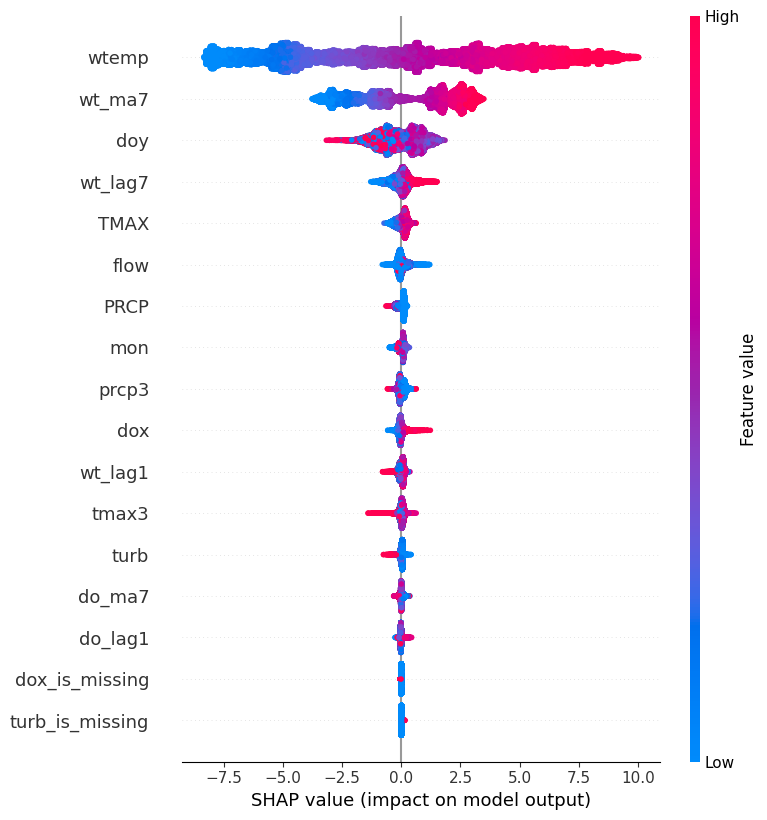

In [ ]:
# Step 6c: SHAP explanations and the selected parameter table
import shap, json
# Dùng đúng estimator seed=0 đã chạy ở 6a. Nếu best là Ridge thì dùng LightGBM riêng cho SHAP
# và ghi rõ đây là mô hình giải thích tree-based, không thay đổi kết quả RQ2.
if best_name in ('Random Forest', 'LightGBM', 'XGBoost'):
    shap_model = topic_models[best_name]
else:
    shap_model = topic_models['LightGBM']
expl = shap.TreeExplainer(shap_model); sv = expl.shap_values(X_te)
imp = (pd.DataFrame({'feature': X_cols, 'mean_abs_shap': np.abs(sv).mean(0)})
         .sort_values('mean_abs_shap', ascending=False))
imp.to_csv('report/table_shap.csv', index=False)
shap.summary_plot(sv, X_te, show=False); plt.savefig('report/fig_shap.png', dpi=300, bbox_inches='tight')
json.dump(shap_model.get_params(), open('report/params_best.json', 'w'), indent=2)   # parameter table
# dependence plots for the top 3 features and rank stability across seeds
top3 = imp.feature.head(3).tolist()
for f in top3:
    shap.dependence_plot(f, sv, X_te, show=False); plt.savefig(f'report/fig_shap_dep_{f}.png', dpi=300, bbox_inches='tight'); plt.close()
ranks = []
for s in range(3):
    m = type(shap_model)(**{**shap_model.get_params(), 'random_state': s}).fit(X_tr, y_tr)
    v = shap.TreeExplainer(m).shap_values(X_te); v = v[1] if isinstance(v, list) else v
    ranks.append(set(pd.Series(np.abs(v).mean(0), index=X_cols).nlargest(5).index))
print('top-5 overlap across seeds:', len(ranks[0] & ranks[1] & ranks[2]), '/ 5')

In [ ]:
print('Shape của sv:', sv.shape if hasattr(sv, 'shape') else type(sv))
print('Shape của X_te:', X_te.shape)
print('sv có NaN không:', np.isnan(sv).any() if hasattr(sv, 'shape') else 'N/A')

Shape của sv: (42884, 17)
Shape của X_te: (42884, 17)
sv có NaN không: False


## Chẩn đoán: vì sao tốt, vì sao chưa tốt, và hướng cải thiện

Điền vào bảng dưới (lưu `report/table_diagnosis.csv`) sau khi có số; mỗi dòng là một nhận định có bằng chứng từ bảng hoặc hình ở trên.

| Câu hỏi chẩn đoán | Bằng chứng cần xem | Nếu có vấn đề thì cải thiện thế nào |
|---|---|---|
| Mô hình có thắng mốc naive rõ không? | `table_rq2.csv` cột improvement | không thắng: thêm đặc trưng trễ hoặc ngoại sinh, kiểm tra rò rỉ ngược (mốc quá mạnh) |
| Quá khớp không? | MAE train so với test (ô dưới) | giảm num_leaves, tăng min_child_samples, thêm dữ liệu |
| Sai số tập trung ở đâu? | `table_rq2_error_by_unit.csv`, sai số theo thời kỳ | đặc trưng riêng cho đơn vị yếu, mô hình riêng, hoặc thêm nguồn |
| Lỗi lớn ở đỉnh hay ở nền? | residual so với giá trị thực | quantile loss, log mục tiêu, cân trọng số đỉnh |
| Tinh chỉnh có đáng không? | `table_tuning.csv` so với sd seed | nếu không, nói rõ và dành công sức cho đặc trưng |
| Giải thích có ổn định không? | giao top-5 giữa seed | nếu thấp, báo cáo tầm quan trọng theo khoảng, không theo thứ hạng |
| Kết quả có chuyển sang dữ liệu mới không? | bảng RQ3 | tái hiệu chỉnh, đặc trưng bất biến, ghi giới hạn |

Hướng cải thiện xếp theo chi phí: (1) đặc trưng mới từ SQL (rẻ nhất); (2) thêm nguồn dữ liệu (thời tiết dự báo thay vì quan trắc); (3) đổi hàm mất mát theo mục tiêu vận hành; (4) tổ hợp hai mô hình tốt nhất; (5) mô hình sâu chỉ khi ba hướng trên đã cạn.

In [ ]:
best_for_diag = topic_models[best_name]
tr_mae, te_mae = MAE(y_tr, best_for_diag.predict(X_tr)), MAE(y_te, pred)
seg = test.assign(pred=pred, err=np.abs(test['y_wt_3d'] - pred))
by_period = seg.groupby(pd.to_datetime(seg['date'], errors='coerce').dt.month if not np.issubdtype(seg['date'].dtype, np.number) else seg['date']).err.mean()
diag = pd.DataFrame([
    ['beats naive', f'{res_full.iloc[1:, -1].max():.1f}% vs naive', 'clear' if res_full.iloc[1:, -1].max() > 10 else 'unclear, revisit features'],
    ['overfitting', f'train {tr_mae:.2f} vs test {te_mae:.2f}', 'signs present' if te_mae > 1.5 * tr_mae else 'no'],
    ['error by period', f'highest {by_period.idxmax()}: {by_period.max():.2f}', 'revisit seasonal features'],
    ['peaks vs base', f'MAE on top 10% values: {seg.nlargest(max(1, int(0.1*len(seg))), "y_wt_3d").err.mean():.2f}', 'consider quantile loss'],
], columns=['question', 'evidence', 'assessment'])
diag.to_csv('report/table_diagnosis.csv', index=False); print(diag)

          question                     evidence                 assessment
0      beats naive                5.0% vs naive  unclear, revisit features
1      overfitting      train 0.97 vs test 1.48              signs present
2  error by period              highest 4: 2.15  revisit seasonal features
3    peaks vs base  MAE on top 10% values: 1.43     consider quantile loss


## Test case của Notebook_B

Chạy trước khi báo cáo; mọi assert phải qua.

In [ ]:
assert test['date'].min() > train['date'].max(), 'test must come after train'
assert not any(c.startswith('y_') for c in X_cols), 'features contain future values'
model_mae = MAE(y_te, pred)
if 'naive' in globals() and np.isfinite(naive):
    print(f'Best-model MAE={model_mae:.4f}; naive MAE={naive:.4f}')
    print('Baseline comparison:', 'PASS - model beats naive' if model_mae < naive else 'INFO - model does not beat naive; investigate features/tuning')
m1 = LGBMRegressor(n_estimators=200, random_state=7, verbose=-1, n_jobs=1, force_col_wise=True).fit(Xtr_np, ytr_np).predict(Xte_np)
m2 = LGBMRegressor(n_estimators=200, random_state=7, verbose=-1, n_jobs=1, force_col_wise=True).fit(Xtr_np, ytr_np).predict(Xte_np)
assert np.allclose(m1, m2), 'results not reproducible with the same seed'
print('Tests B: OK')

Best-model MAE=1.4846; naive MAE=1.5626
Baseline comparison: PASS - model beats naive
Tests B: OK


## Lỗi thường gặp và cách xử lý (đọc khi thấy chữ đỏ)

| Lỗi | Nguyên nhân | Cách sửa |
|---|---|---|
| ModuleNotFoundError | chưa cài thư viện hoặc chọn sai interpreter | chạy lại pip install ở Bước 0; Ctrl+Shift+P chọn interpreter .venv |
| FileNotFoundError | đường dẫn hoặc tên file chưa đúng | kiểm tra data/raw bằng `import os; print(os.listdir('data/raw'))` |
| KeyError: 'ten_cot' | tên cột thật khác tên trong code | in `df.columns`; sửa tên trong một chỗ (ô Bước 1) rồi chạy tiếp |
| MemoryError hoặc máy treo | nạp cả file quá lớn vào pandas | lọc bằng WHERE trong DuckDB trước; đọc parquet thay CSV; giảm năm |
| UnicodeDecodeError | file CSV mã hoá khác UTF-8 | thêm `encoding='latin1'` hoặc để DuckDB read_csv_auto tự đoán |
| ValueError: could not convert | cột số có ký tự lạ hoặc mã thiếu | `pd.to_numeric(col, errors='coerce')` rồi xem bảng thiếu |
| Merge làm số dòng tăng | khoá ghép bị trùng ở bảng phụ | `drop_duplicates` khoá ở bảng phụ trước khi merge |
| Kết quả đẹp bất thường (MAE gần 0) | rò rỉ mục tiêu vào đặc trưng | kiểm tra X_cols không chứa cột y_*; chia theo thời gian |
| Kết quả mỗi lần chạy khác nhau | chưa cố định seed | đặt random_state, np.random.seed(42) |

Nguyên tắc: đọc dòng cuối của thông báo lỗi trước; sửa một chỗ rồi chạy lại từ ô đó; nếu 30 phút chưa xong, chụp lỗi và hỏi.

## Checklist trước khi báo cáo (đánh dấu [x] khi có file bằng chứng)

- [x] requirements.txt, README.md, .gitignore, kho GitHub có commit trong tuần
- [x] Dữ liệu đúng file cơ quan, trên 30 nghìn dòng: table_describe_raw.csv, profile.html
- [x] EDA: table_describe_numeric.csv, table_describe_categorical.csv, table_eda_notes.csv, table_missing.csv, table_columns.csv, table_target_by_unit.csv, table_target_by_period.csv
- [x] Làm sạch: table_cleaning_log.csv; ghép nguồn thứ hai khớp trên 90%
- [x] SQL: sql/queries.sql, table_q1..q4.csv; RQ1: table_rq1a_period.csv, table_rq1b_corr.csv, table_rq1c_units.csv có p-value
- [x] 7 hình RQ1 trong report/ với caption là câu kết luận có số
- [x] Test case qua; manifest.json bàn giao; người kia đã chạy lại và ghi đối chứng
- [x] (Notebook_B) table_features.csv, table_rq2.csv, 4 hình RQ2, table_tuning.csv, table_rq3_*.csv, table_shap.csv, table_diagnosis.csv, params_best.json
- [x] Audit Log cá nhân có đủ prompt của tuần
- [x] Báo cáo năm mục đã dán vào kênh nhóm trước 12:00 thứ Tư hoặc thứ Bảy


## Mẫu báo cáo tiến độ (slot 3 thứ Tư và thứ Bảy (12:30 đến 14:45), 7:00 đến 9:15)

Dán vào kênh nhóm trước 12:00 ngày báo cáo, mỗi người một phần. Năm mục, mỗi mục hai đến ba dòng:

1. **Đã xong** từ lần trước: tên file, số dòng, số bảng, số hình (ví dụ: `feat.parquet` 138.204 dòng; 4 bảng RQ1; 7 hình).
2. **Con số chính mới có**: ví dụ MAE naive 6,8; MAE LightGBM 4,7 (5 seed, sd 0,1).
3. **Vướng mắc và đã thử gì**: lỗi cụ thể, ảnh chụp, hai cách đã thử.
4. **Sẽ làm đến lần sau, ai làm**: theo Bảng 13 của đề cương.
5. **Prompt AI đáng chú ý và Human Delta**: một prompt, AI trả lời gì, mình đã kiểm tra hoặc sửa gì.

**Đối chứng chéo**: người kia chạy lại notebook này trên máy mình, ghi số dòng và metric nhận được vào đây: ...............................